![earthkit-hydro-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg)

# Earthkit-hydro: Computing Catchment Statistics

Tnis notebook will show a simple example of computing catchment statistics.

In [12]:
import earthkit.plots as ekp
import earthkit.hydro as ekh
import earthkit.data as ekd

In [ ]:
network = ekh.river_network.load("efas", "5")

da = ekd.from_source(
    "sample",
    "R06a.nc",
)[0].to_xarray()

River network not found in cache (/var/folders/td/yqnxcqpx39dc855vwjtv5hj40000gn/T/tmpbck4c78s_earthkit_hydro/1.1_60f3ec02b618c7fda7d71dc5219032531209e5b13663d65f7651d5370375fe15.joblib).
Loading river network from cache (/var/folders/td/yqnxcqpx39dc855vwjtv5hj40000gn/T/tmpbck4c78s_earthkit_hydro/1.1_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).


In practice, computing full-field accumulations is often not required and users may wish to calculate only for certain areas of interest. In hydrology, the canonical unit over which to calculate is typically a catchment.

In earthkit-hydro, catchments are specified by specifying the location of the most downstream cell.

As an example, we specify two disjoint catchments in this notebook.

In [9]:
locations={
    "gauge_1": (70.475, 28.32),
    "gauge_2": (42.225, 50.24)
}

To begin, we visualise the catchments to confirm we have correctly specified the right location on the river network.

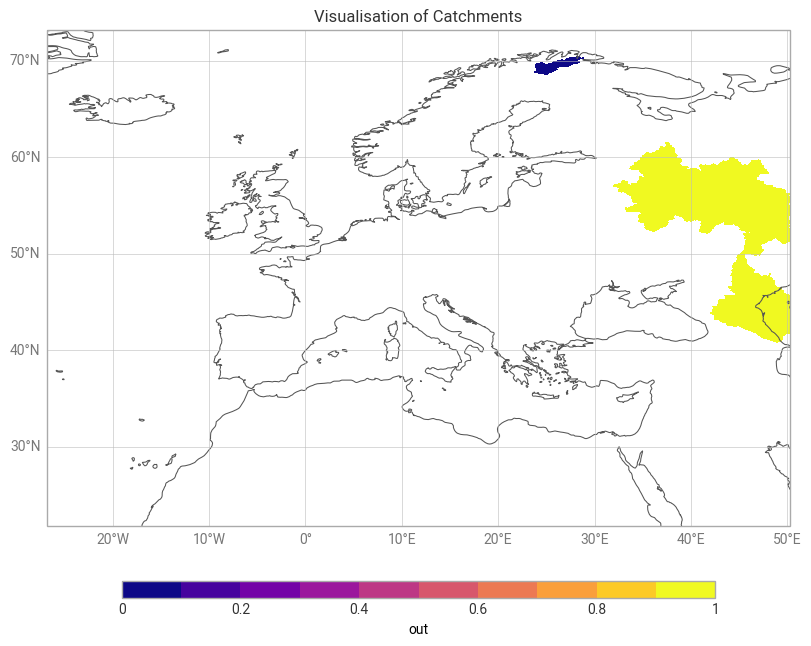

In [ ]:
find_catchments = ekh.catchments.find(network, locations)

chart = ekp.Map()
chart.quickplot(find_catchments)
chart.legend(label="{variable_name}")
chart.title("Visualisation of Catchments")
chart.coastlines()
chart.gridlines()
chart.show()

We can then easily compute catchment statistics over these areas. Many metrics are available. As an example, we compute catchment averages for both gauge locations.

In [ ]:
ekh.catchments.mean(network, da, locations)

<xarray.DataArray 'R06a' (node_index: 2)> Size: 16B
array([3.87362952, 0.55086687])
Coordinates:
  * node_index  (node_index) int64 16B 26066 4153831
    time        datetime64[ns] 8B 2024-11-14T06:00:00
    lat         (node_index) float64 16B 70.47 42.23
    lon         (node_index) float64 16B 28.32 50.24
    name        (node_index) <U7 56B 'gauge_1' 'gauge_2'